# AI-Based 5G Network Congestion Prediction and Load Balancing System

This notebook presents a systems-oriented AI workflow for predicting 5G network congestion and recommending load-balancing actions. Instead of treating congestion prediction as an isolated machine learning task, the notebook connects data-driven prediction to operational decision-making that can support network optimization.

Congestion prediction matters in 5G because user density, application demand, mobility, and radio conditions can change rapidly. When congestion is identified early, network operators can react before latency increases, throughput drops, or connection quality degrades for end users.

The problem addressed here is how to convert raw network telemetry into an actionable pipeline that can classify congestion severity and trigger practical responses such as traffic steering, tower switching, or load reduction. This makes the project relevant not only for AI modeling, but also for intelligent network management.

High-level pipeline:

`Dataset -> Preprocessing -> Neural Network (TELU) -> Prediction -> Decision Engine -> Optimization`

The final outcome is a compact prototype of an AI-assisted 5G decision support system that combines congestion classification with simple network optimization logic.

### 1. Import Libraries

This section imports the libraries required for data handling, preprocessing, neural network modeling, evaluation, and visualization. It also enables automatic device detection so the notebook can use a CUDA-enabled GPU when available and fall back to CPU execution otherwise.

GPU support is useful because tensor operations and neural network training can run significantly faster on parallel hardware. Even so, the notebook is designed to remain fully functional on CPU-based systems for portability and easier reproduction.

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 2. Load Dataset

This section loads the 5G telemetry dataset that contains signal, latency, throughput, device, and congestion-related measurements. Loading the dataset early allows us to inspect the raw network attributes before transforming them into model-ready features.

Link = "https://www.kaggle.com/datasets/vinothkannaece/5g-network-data/data"

In [3]:
# Load the raw 5G telemetry dataset used for congestion prediction.
df = pd.read_csv("5g_network_data.csv")
df.head()

,Timestamp,Location,Signal Strength (dBm),Download Speed (Mbps),Upload Speed (Mbps),Latency (ms),Jitter (ms),Network Type,Device Model,Carrier,...,Battery Level (%),Temperature (°C),Connected Duration (min),Handover Count,Data Usage (MB),Video Streaming Quality,VoNR Enabled,Network Congestion Level,Ping to Google (ms),Dropped Connection
0,2025-05-28 06:59:51.089339,San Francisco,-108.6,714.94,60.41,10.0,4.09,5G NSA,iPhone 14,AT&T,...,99,35.5,14,1,97.40,4,False,High,27.9,True
1,2025-05-28 06:49:51.089353,San Francisco,-71.5,686.69,148.70,12.3,1.50,4G,Pixel 7,AT&T,...,67,22.0,51,4,143.23,3,True,Medium,22.2,False
2,2025-05-28 06:39:51.089356,Chennai,-67.5,796.34,136.33,19.9,1.22,5G NSA,iPhone 14,Airtel,...,77,36.1,45,2,179.15,5,False,Low,75.5,False
3,2025-05-28 06:29:51.089360,New York,-73.3,208.56,68.59,12.2,4.94,4G,Pixel 7,T-Mobile,...,25,39.3,48,0,128.87,4,False,High,87.5,False
4,2025-05-28 06:19:51.089363,Kolkata,-93.2,409.85,137.23,6.3,2.94,5G NSA,Galaxy S23,BSNL,...,51,22.7,54,4,156.91,1,True,Medium,32.5,True


### 3. Data Cleaning & Preprocessing

This stage standardizes the raw schema and prepares the dataset for numerical modeling. Cleaning is necessary because real-world telecom data often contains spaces, symbols, timestamps, and boolean fields that are inconvenient for tensor-based learning pipelines.

The preprocessing steps below keep the original logic intact while making the dataset consistent, machine-readable, and easier to reference throughout the notebook.

In [4]:
# Standardize column names so later feature access is clean and consistent.
df.columns = (
    df.columns.str.strip()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

# Convert boolean service indicators into numeric flags because neural networks require numeric inputs.
df["VoNR_Enabled"] = df["VoNR_Enabled"].astype(int)
df["Dropped_Connection"] = df["Dropped_Connection"].astype(int)

# Remove the timestamp because this version models congestion from snapshot features rather than temporal sequences.
df = df.drop(columns=["Timestamp"], errors="ignore")
df.head()

,Location,Signal_Strength_dBm,Download_Speed_Mbps,Upload_Speed_Mbps,Latency_ms,Jitter_ms,Network_Type,Device_Model,Carrier,Band,Battery_Level,Temperature_C,Connected_Duration_min,Handover_Count,Data_Usage_MB,Video_Streaming_Quality,VoNR_Enabled,Network_Congestion_Level,Ping_to_Google_ms,Dropped_Connection
0,San Francisco,-108.6,714.94,60.41,10.0,4.09,5G NSA,iPhone 14,AT&T,n78,99,35.5,14,1,97.40,4,0,High,27.9,1
1,San Francisco,-71.5,686.69,148.70,12.3,1.50,4G,Pixel 7,AT&T,n260,67,22.0,51,4,143.23,3,1,Medium,22.2,0
2,Chennai,-67.5,796.34,136.33,19.9,1.22,5G NSA,iPhone 14,Airtel,n78,77,36.1,45,2,179.15,5,0,Low,75.5,0
3,New York,-73.3,208.56,68.59,12.2,4.94,4G,Pixel 7,T-Mobile,n41,25,39.3,48,0,128.87,4,0,High,87.5,0
4,Kolkata,-93.2,409.85,137.23,6.3,2.94,5G NSA,Galaxy S23,BSNL,n28,51,22.7,54,4,156.91,1,1,Medium,32.5,1


### 4. Feature Engineering

This section transforms the cleaned dataset into model inputs and target labels. The workflow includes separating predictors from the congestion label, encoding categorical attributes, normalizing feature ranges, and creating a fixed train-test split.

Encoding is required because columns such as carrier, device model, and network type are categorical and cannot be passed directly to the neural network. Normalization is used because latency, throughput, signal strength, and usage operate on very different numeric scales; scaling them to a comparable range helps stabilize gradient-based optimization and prevents larger-valued features from dominating training.

A fixed split is used instead of a random split so the row order is preserved. This is safer for time-aware or sequential network datasets because it avoids leaking future records into training and makes evaluation more realistic.

In [5]:
y = df["Network_Congestion_Level"]

# Preserve an unscaled feature copy so the later decision engine can inspect real network values.
X_original = df.drop(columns=["Network_Congestion_Level"]).copy()
X = X_original.copy()

# One-hot encoding converts categorical telecom attributes into binary indicators without inventing an artificial ordering.
X = pd.get_dummies(X)
feature_columns = X.columns

# Map congestion labels to class indices expected by the neural network loss function.
y = y.map({"Low": 0, "Medium": 1, "High": 2})

if y.isna().any():
    raise ValueError("Unexpected labels found in Network_Congestion_Level.")

# Use a fixed chronological split to preserve order: first 40,000 rows for training, remaining rows for testing.
# This keeps the evaluation closer to a real deployment setting where future observations should not influence training.
split_index = 40000
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()
X_train_original = X_original.iloc[:split_index].reset_index(drop=True)
X_test_original = X_original.iloc[split_index:].reset_index(drop=True)

# Fit normalization on the training window only, then apply the same transform to the held-out test window.
# This avoids letting future data influence the feature scaling used during training.
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Move tensors onto the selected device so training and inference can use GPU acceleration when available.
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test = torch.tensor(X_test, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train.values, dtype=torch.long, device=device)
y_test = torch.tensor(y_test.values, dtype=torch.long, device=device)

print(f"Train samples: {len(X_train_original)}, Test samples: {len(X_test_original)}")

Train samples: 40000, Test samples: 10000


### 5. Model Definition (TELU Activation)

This section defines the neural network used for multiclass congestion prediction. The model is a compact feed-forward architecture with two hidden layers and a final output layer that produces logits for the three congestion classes: Low, Medium, and High.

TELU is retained as the core activation function because it provides a smoother nonlinearity than ReLU and can preserve more information from both positive and negative inputs. In this project, TELU is used to explore whether a smoother activation can model complex 5G feature interactions more effectively than a hard-threshold activation such as ReLU.

In [6]:
class TELU(nn.Module):
    def forward(self, x):
        # TELU applies a smooth nonlinear response that avoids the abrupt zeroing behavior of ReLU.
        return x * torch.tanh(torch.exp(x))


class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            TELU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            TELU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            TELU(),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)

model = Net(X_train.shape[1]).to(device)

### 6. Training and Model Saving

This stage optimizes the neural network parameters using cross-entropy loss and the Adam optimizer. Training is necessary so the model can learn how combinations of signal quality, throughput, latency, and device context relate to congestion severity.

The loop below preserves the original TELU-based model while adding clearer logging and model persistence. Saving the trained weights is important because it makes the run reproducible, supports later evaluation without retraining, and provides a clean handoff point for deployment or comparison experiments.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(30):
    # Training mode ensures the model is ready for gradient-based weight updates.
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Reset old gradients, propagate the current error backward, and update the network weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Per-epoch logging makes the training trajectory visible and easier to debug or compare across runs.
    print(f"Epoch {epoch + 1}/30, Loss: {loss.item():.4f}")

# Save the learned weights so the trained model can be reused without rerunning the full training loop.
torch.save(model.state_dict(), "model.pth")
print("Saved trained model to model.pth")

Epoch 1/30, Loss: 1.1137
Epoch 2/30, Loss: 1.1094
Epoch 3/30, Loss: 1.1072
Epoch 4/30, Loss: 1.1061
Epoch 5/30, Loss: 1.1055
Epoch 6/30, Loss: 1.1034
Epoch 7/30, Loss: 1.1033
Epoch 8/30, Loss: 1.1026
Epoch 9/30, Loss: 1.1023
Epoch 10/30, Loss: 1.1010
Epoch 11/30, Loss: 1.1015
Epoch 12/30, Loss: 1.1004
Epoch 13/30, Loss: 1.0997
Epoch 14/30, Loss: 1.0995
Epoch 15/30, Loss: 1.0997
Epoch 16/30, Loss: 1.0991
Epoch 17/30, Loss: 1.0994
Epoch 18/30, Loss: 1.0985
Epoch 19/30, Loss: 1.0982
Epoch 20/30, Loss: 1.0974
Epoch 21/30, Loss: 1.0982
Epoch 22/30, Loss: 1.0974
Epoch 23/30, Loss: 1.0977
Epoch 24/30, Loss: 1.0975
Epoch 25/30, Loss: 1.0970
Epoch 26/30, Loss: 1.0969
Epoch 27/30, Loss: 1.0968
Epoch 28/30, Loss: 1.0967
Epoch 29/30, Loss: 1.0972
Epoch 30/30, Loss: 1.0968
Saved trained model to model.pth


#### Optional: Reload Saved Model

This optional cell reloads the saved weights from disk. It is useful when the notebook is reopened later, when evaluation needs to be repeated without retraining, or when the trained model is moved into a separate inference workflow.

In [8]:
# Reload the persisted weights into the current model instance to reproduce inference from a saved checkpoint.
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()
print("Reloaded model weights from model.pth")

Reloaded model weights from model.pth


### 7. Evaluation and Saved Outputs

Evaluation measures how well the trained model generalizes to unseen test data. Accuracy gives a compact summary of overall performance, while the classification report and confusion matrix reveal where the model distinguishes congestion levels well and where misclassifications still occur.

Because the model may run on GPU, the predictions are moved back to CPU-compatible arrays before using scikit-learn evaluation utilities. The notebook also saves predictions and metrics so the run leaves behind reproducible artifacts that can be reviewed, compared, and audited later.

In [9]:
model.eval()
with torch.no_grad():
    preds = model(X_test)
    _, predicted = torch.max(preds, 1)

# Convert tensors to CPU arrays because scikit-learn metrics and file export routines operate on NumPy/Pandas data.
y_test_np = y_test.cpu().numpy()
predicted_np = predicted.cpu().numpy()
test_accuracy = (predicted == y_test).float().mean().item()
label_names = {0: "Low", 1: "Medium", 2: "High"}
classification_text = classification_report(
    y_test_np,
    predicted_np,
    labels=[0, 1, 2],
    target_names=["Low", "Medium", "High"],
    zero_division=0
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(classification_text)
print(confusion_matrix(y_test_np, predicted_np, labels=[0, 1, 2]))

# Saving per-sample predictions supports error analysis, traceability, and comparison against future model versions.
results_df = pd.DataFrame({
    "actual_label": [label_names[label] for label in y_test_np],
    "predicted_label": [label_names[label] for label in predicted_np]
})
results_df.to_csv("test_results.csv", index=False)

# Saving metrics to a text file creates a lightweight experiment record that can be shared or inspected without rerunning the notebook.
with open("metrics.txt", "w", encoding="utf-8") as metrics_file:
    metrics_file.write(f"Accuracy: {test_accuracy:.4f}\n\n")
    metrics_file.write("Classification Report:\n")
    metrics_file.write(classification_text)

print("Saved test predictions to test_results.csv")
print("Saved evaluation metrics to metrics.txt")

Test Accuracy: 0.3271
              precision    recall  f1-score   support

         Low       0.33      0.39      0.36      3388
      Medium       0.32      0.56      0.41      3305
        High       0.33      0.04      0.06      3307

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.28     10000
weighted avg       0.33      0.33      0.28     10000

[[1306 1943  139]
 [1360 1849   96]
 [1266 1925  116]]
Saved test predictions to test_results.csv
Saved evaluation metrics to metrics.txt


### 8. Decision Engine: Multi-Parameter Network Optimization

Prediction alone is not enough for a real-world 5G optimization system. A neural network can estimate whether congestion is likely to be Low, Medium, or High, but the network still needs a decision layer that interprets live conditions and chooses an operational response.

This section adds that decision-making layer by combining the model output with a multi-parameter network stress score. Instead of reacting to only one threshold, the system evaluates latency, jitter, ping, throughput, signal strength, data usage, and handover activity together. This makes the decision process more robust, more interpretable, and closer to how practical telecom optimization systems weigh multiple quality and reliability signals before triggering load balancing or traffic steering.

In modern 5G operations, prediction helps anticipate congestion, while decision logic uses several network indicators to prevent overload, improve throughput, and maintain quality of service. The goal here is to keep that logic explainable while still reflecting real system thinking.

In [10]:
# Build normalization ranges from the original feature space so each network indicator contributes on a comparable scale.
# This mirrors real optimization systems, where multiple telemetry streams are combined instead of relying on a single threshold.
stress_feature_ranges = {
    "Latency_ms": (X_original["Latency_ms"].min(), X_original["Latency_ms"].max()),
    "Jitter_ms": (X_original["Jitter_ms"].min(), X_original["Jitter_ms"].max()),
    "Ping_to_Google_ms": (X_original["Ping_to_Google_ms"].min(), X_original["Ping_to_Google_ms"].max()),
    "Download_Speed_Mbps": (X_original["Download_Speed_Mbps"].min(), X_original["Download_Speed_Mbps"].max()),
    "Upload_Speed_Mbps": (X_original["Upload_Speed_Mbps"].min(), X_original["Upload_Speed_Mbps"].max()),
    "Signal_Strength_dBm": (X_original["Signal_Strength_dBm"].min(), X_original["Signal_Strength_dBm"].max()),
    "Data_Usage_MB": (X_original["Data_Usage_MB"].min(), X_original["Data_Usage_MB"].max()),
    "Handover_Count": (X_original["Handover_Count"].min(), X_original["Handover_Count"].max())
}

stress_weights = {
    "Latency_ms": 0.20,
    "Jitter_ms": 0.12,
    "Ping_to_Google_ms": 0.13,
    "Download_Speed_Mbps": 0.15,
    "Upload_Speed_Mbps": 0.10,
    "Signal_Strength_dBm": 0.15,
    "Data_Usage_MB": 0.10,
    "Handover_Count": 0.05
}


def normalize_metric(value, min_val, max_val, invert=False):
    # Min-max normalization puts unlike metrics such as latency, throughput, and signal strength onto a shared 0-1 scale.
    # This makes weighted fusion meaningful and prevents large-unit features from dominating the stress score.
    if max_val == min_val:
        return 0.0
    normalized = (value - min_val) / (max_val - min_val)
    normalized = float(np.clip(normalized, 0.0, 1.0))
    return 1.0 - normalized if invert else normalized


def compute_network_stress(row):
    # Latency contributes directly to user-perceived delay and is a core QoS signal for interactive traffic.
    # Jitter captures packet-delay variation, which strongly affects real-time services such as voice and video.
    # Ping provides an additional end-to-end responsiveness view beyond radio-layer metrics alone.
    # Download and upload throughput reflect available bandwidth; lower throughput often indicates growing congestion pressure.
    # Signal strength influences link reliability, retransmissions, and the likelihood of degraded radio performance.
    # Data usage represents current resource demand, while frequent handovers can signal mobility-driven instability.
    # Combining these features is more reliable than single-threshold logic because real telecom conditions degrade across several dimensions at once.
    normalized_metrics = {
        "Latency_ms": normalize_metric(row["Latency_ms"], *stress_feature_ranges["Latency_ms"]),
        "Jitter_ms": normalize_metric(row["Jitter_ms"], *stress_feature_ranges["Jitter_ms"]),
        "Ping_to_Google_ms": normalize_metric(row["Ping_to_Google_ms"], *stress_feature_ranges["Ping_to_Google_ms"]),
        "Download_Speed_Mbps": normalize_metric(row["Download_Speed_Mbps"], *stress_feature_ranges["Download_Speed_Mbps"], invert=True),
        "Upload_Speed_Mbps": normalize_metric(row["Upload_Speed_Mbps"], *stress_feature_ranges["Upload_Speed_Mbps"], invert=True),
        "Signal_Strength_dBm": normalize_metric(row["Signal_Strength_dBm"], *stress_feature_ranges["Signal_Strength_dBm"], invert=True),
        "Data_Usage_MB": normalize_metric(row["Data_Usage_MB"], *stress_feature_ranges["Data_Usage_MB"]),
        "Handover_Count": normalize_metric(row["Handover_Count"], *stress_feature_ranges["Handover_Count"])
    }

    stress_score = sum(
        stress_weights[feature] * normalized_metrics[feature]
        for feature in stress_weights
    )
    return stress_score, normalized_metrics


def optimize_network(row, pred, stress_score):
    # The neural network predicts congestion severity, but the final action also depends on current network stress.
    # This mirrors practical telecom workflows where prediction and decision logic work together to avoid overload and protect throughput.
    latency = row["Latency_ms"]
    jitter = row["Jitter_ms"]
    signal = row["Signal_Strength_dBm"]
    download = row["Download_Speed_Mbps"]
    handovers = row["Handover_Count"]

    if pred == 2:
        if latency > 15 and stress_score >= 0.65:
            return "Route to low latency path"
        if signal < -95 and stress_score >= 0.60:
            return "Switch to stronger cell"
        if jitter > 8 or handovers >= 6:
            return "Stabilize connection"
        return "Immediate load balancing"

    if pred == 1:
        if stress_score >= 0.60:
            return "Immediate load balancing"
        if latency > 15:
            return "Route to low latency path"
        if signal < -95:
            return "Switch to stronger cell"
        if jitter > 8 or handovers >= 6:
            return "Stabilize connection"
        if stress_score >= 0.45 or download < X_original["Download_Speed_Mbps"].median():
            return "Monitor network"
        return "No action"

    if stress_score >= 0.55:
        return "Monitor network"
    if jitter > 8 and signal < -95:
        return "Stabilize connection"
    return "No action"


stress_scores = []
stress_components = []
actions = []

for i in range(len(predicted)):
    # Use the original unscaled row so domain thresholds remain physically meaningful in milliseconds, Mbps, dBm, and usage volume.
    row = X_test_original.iloc[i]
    stress_score, component_scores = compute_network_stress(row)
    stress_scores.append(stress_score)
    stress_components.append(component_scores)
    actions.append(optimize_network(row, predicted[i].item(), stress_score))

decision_preview = pd.DataFrame({
    "Predicted_Congestion": predicted_np,
    "Stress_Score": np.round(stress_scores, 3),
    "Recommended_Action": actions
})

decision_preview.head(10)

,Predicted_Congestion,Stress_Score,Recommended_Action
0,1,0.382,Monitor network
1,1,0.584,Switch to stronger cell
2,1,0.505,Monitor network
3,0,0.511,No action
4,0,0.585,Monitor network
5,0,0.565,Monitor network
6,2,0.343,Immediate load balancing
7,1,0.519,Monitor network
8,0,0.393,No action
9,1,0.621,Immediate load balancing


### 9. Visualization

This visualization summarizes how the trained model distributes its congestion predictions across the test set. A simple class-frequency view is helpful for quickly checking whether the model is overly biased toward one congestion category or whether its predictions are spread across all three operating states.

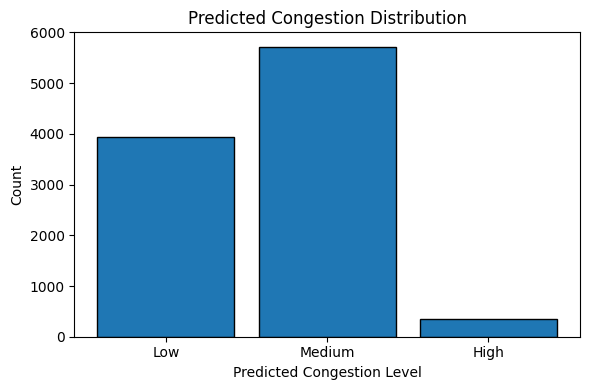

In [11]:
plt.figure(figsize=(6, 4))
# Center histogram bins on the three class ids so each bar corresponds to one congestion level.
plt.hist(predicted_np, bins=np.arange(-0.5, 3.5, 1), edgecolor="black", rwidth=0.85)
plt.xticks([0, 1, 2], ["Low", "Medium", "High"])
plt.title("Predicted Congestion Distribution")
plt.xlabel("Predicted Congestion Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 10. Final Summary

This concluding section connects the machine learning output to the broader 5G systems perspective. It highlights what the model achieved, how the decision engine responds, why the approach is relevant to real network operations, and where the current prototype can be extended in future work.

In [13]:
summary_lines = [
    "Project Summary",
    f"- Achieved test accuracy: {test_accuracy:.4f}",
    "- The TELU-based neural network predicts three congestion states: Low, Medium, and High.",
    "- The decision engine combines predicted congestion with a multi-parameter stress score to trigger actions such as immediate load balancing, stronger-cell switching, low-latency routing, stabilization, monitoring, or no action.",
    "- This reflects how AI can support real 5G systems by linking predictive analytics with congestion-aware load balancing and operational response.",
    "- Current limitations include offline analysis, snapshot-based features, static threshold rules, and the absence of multi-cell or real-time control feedback.",
    "- Possible improvements include reinforcement learning for adaptive policies, real-time telemetry ingestion, multi-cell simulation, richer temporal modeling, and tighter integration with network orchestration frameworks."
]

print("\n".join(summary_lines))

Project Summary
- Achieved test accuracy: 0.3271
- The TELU-based neural network predicts three congestion states: Low, Medium, and High.
- The decision engine combines predicted congestion with a multi-parameter stress score to trigger actions such as immediate load balancing, stronger-cell switching, low-latency routing, stabilization, monitoring, or no action.
- This reflects how AI can support real 5G systems by linking predictive analytics with congestion-aware load balancing and operational response.
- Current limitations include offline analysis, snapshot-based features, static threshold rules, and the absence of multi-cell or real-time control feedback.
- Possible improvements include reinforcement learning for adaptive policies, real-time telemetry ingestion, multi-cell simulation, richer temporal modeling, and tighter integration with network orchestration frameworks.
